In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import os
import re
import glob


  20 agents →    475 samples
  60 agents →   1300 samples
 100 agents →   2650 samples
 140 agents →   3425 samples
 180 agents →   3600 samples
 220 agents →   3800 samples
 260 agents →   3550 samples
 300 agents →   6875 samples
 340 agents →   6975 samples
 380 agents →   7100 samples
 420 agents →   7600 samples
 460 agents →   7634 samples
 500 agents →   7800 samples
 540 agents →   7657 samples
 580 agents →   8149 samples
 620 agents →   8095 samples
 660 agents →   7769 samples
 700 agents →   7752 samples
 740 agents →   8110 samples
 780 agents →   7924 samples


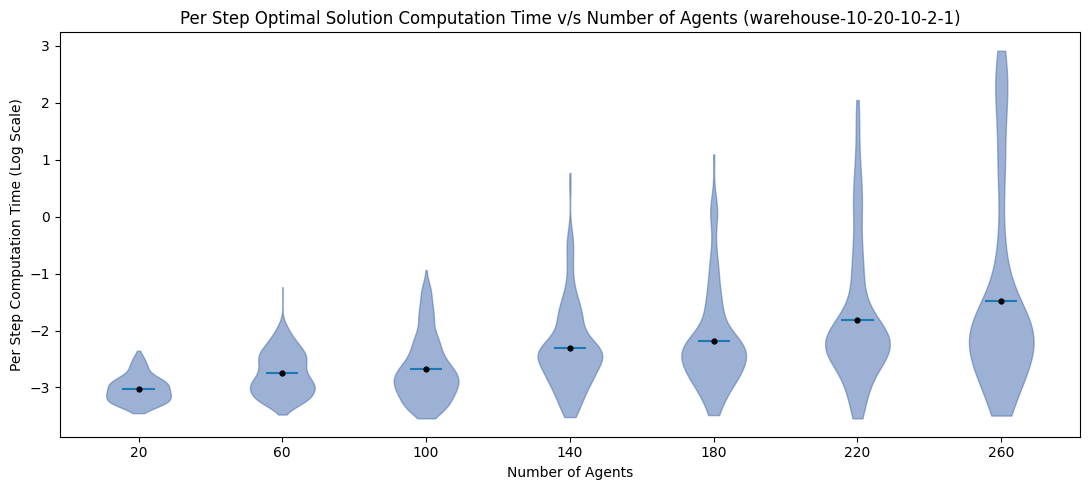

In [ ]:
# ─────────────────────  VIOLIN PLOTS FOR OPTIMAL SOLVING TIME  ───────────────────
# Assumes you already executed:  import glob, os, re, numpy as np, matplotlib.pyplot as plt

# 1)  Collect and clean the data -------------------------------------------------
pattern = re.compile(r'times1_(\d+)_(\d+)\.txt')   #   times1_<scen>_<agents>.txt
data = {}                                          # {agents : [run‑times (ns)]}

for fp in glob.glob("outputs/times1_*.txt"):
    m = pattern.match(os.path.basename(fp))
    if not m:                       # skip files that don’t follow the pattern
        continue
    _, agents = map(int, m.groups())

    vals = np.loadtxt(fp, ndmin=1, dtype=np.int64)   # load column of ints
    vals = vals[vals >= 0]                           # drop any negative timers
    if vals.size:                                    # keep only non‑empty lists
        data.setdefault(agents, []).extend(vals)

# Optional: print a summary
for a in sorted(data):
    print(f"{a:4d} agents → {len(data[a]):6d} samples")

agent_subset = [a for a in data if a <= 260]
# 2)  Prepare datasets -----------------------------------------------------------
agents      = sorted(agent_subset)                          # x‑positions
times_ms    = [np.array(data[a]) / 1e6 for a in agents]   # ns → ms (readable)

# ── 3. Plot (log‑scaled y‑axis) ────────────────────────────────────────────────
# --- transform to log space ----------------------------------------------------
log_times = [np.log10(d) for d in times_ms]    # log10(ms)

fig, ax = plt.subplots(figsize=(11, 5))

parts = ax.violinplot(
    log_times,
    positions=agents,
    widths=18,
    bw_method=0.3,
    showmeans=True,
    showmedians=False,
    showextrema=False,
    # scale='width'
)

for body in parts['bodies']:
    body.set_facecolor('#4C72B0')
    body.set_edgecolor('#4C72B0')
    body.set_alpha(0.55)

# mean markers (still in log space)
ax.scatter(agents, [np.log10(d).mean() for d in times_ms],
           color='black', s=12, zorder=3)

ax.set_ylabel("Per Step Computation Time (Log Scale)")
ax.set_xlabel("Number of Agents")
ax.set_xticks(agents)
ax.set_title("Per Step Optimal Solution Computation Time v/s Number of Agents (ht_chantry)")

plt.tight_layout()
plt.show()



In [ ]:
# Path to the CSV file den520d
csv_file_path1 = "outputs/12x3_runs/lacam/lacam_den20d_agentsweep.csv"  #lacam + anytime pibt (weighted deadline per group size)
csv_file_path2 = "outputs/12x3_runs/pibt3/pibt_den520d_agentsweep.csv"  #vanilla v/s anytime pibt
csv_file_path3 = "outputs/12x3_runs/lacam2/lacam_den20d_agentsweep_woskip.csv"  #lacam2
csv_file_path1t = "outputs/tiebreak/lacam/lacam_den20d_agentsweep.csv"  #lacam + anytime pibt (weighted deadline per group size)
csv_file_path2t = "outputs/tiebreak/pibt3/pibt_den520d_agentsweep.csv"  #vanilla v/s anytime pibt
csv_file_path3t = "outputs/tiebreak/lacam2/lacam_den20d_agentsweep_woskip.csv"  #lacam2
# csv_file_path31 = "outputs/12x3_runs/lacam2/lacam2_0/lacam_den20d_agentsweep_woskip.csv"  #lacam2
# csv_file_path3 = "outputs/12x3_runs/lacam2/lacam2_final/merged_dataset_0.csv"  #lacam2

# 323220
csv_file_path4 = "outputs/12x3_runs/lacam/lacam_323220_agentsweep_wskip.csv"  #lacam + anytime pibt (weighted deadline per group size)
csv_file_path5 = "outputs/12x3_runs/pibt3/pibt_323220_agentsweep.csv"  #vanilla v/s anytime pibt
csv_file_path6 = "outputs/12x3_runs/lacam2/lacam_323220_agentsweep_woskip.csv"  #lacam2
csv_file_path4t = "outputs/tiebreak/lacam/lacam_323220_agentsweep_wskip.csv"  #lacam + anytime pibt (weighted deadline per group size)
csv_file_path5t = "outputs/tiebreak/pibt3/pibt_323220_agentsweep.csv"  #vanilla v/s anytime pibt
csv_file_path6t = "outputs/tiebreak/lacam2/lacam_323220_agentsweep_woskip.csv"  #lacam2
# csv_file_path61 = "outputs/12x3_runs/lacam2/lacam2_0/lacam_323220_agentsweep_woskip.csv"  #lacam2
# csv_file_path6 = "outputs/12x3_runs/lacam2/lacam2_final/merged_dataset_1.csv"  #lacam2

# htc
csv_file_path7 = "outputs/12x3_runs/lacam/lacam_htchantry_agentsweep.csv"  #lacam + anytime pibt (weighted deadline per group size)
csv_file_path8 = "outputs/12x3_runs/pibt3/pibt_htchantry_agentsweep.csv"  #vanilla v/s anytime pibt
csv_file_path9 = "outputs/12x3_runs/lacam2/lacam_htchantry_agentsweep_woskip.csv"  #lacam2
csv_file_path7t = "outputs/tiebreak/lacam/lacam_htchantry_agentsweep.csv"  #lacam + anytime pibt (weighted deadline per group size)
csv_file_path8t = "outputs/tiebreak/pibt3/pibt_htchantry_agentsweep.csv"  #vanilla v/s anytime pibt
csv_file_path9t = "outputs/tiebreak/lacam2/lacam_htchantry_agentsweep_woskip.csv"  #lacam2
# csv_file_path91 = "outputs/12x3_runs/lacam2/lacam2_0/lacam_htchantry_agentsweep_woskip.csv"  #lacam2
# csv_file_path9 = "outputs/12x3_runs/lacam2/lacam2_final/merged_dataset_2.csv"  #lacam2

# warehouse
csv_file_path10 = "outputs/12x3_runs/lacam/lacam_warehouse1.csv"  #lacam + anytime pibt (weighted deadline per group size)
csv_file_path11 = "outputs/12x3_runs/pibt3/pibt_warehouse1_agentsweep.csv"  #vanilla v/s anytime pibt
csv_file_path12 = "outputs/12x3_runs/lacam2/lacam_warehouse1_agentsweep_woskip.csv"  #lacam2
csv_file_path10t = "outputs/tiebreak/lacam/lacam_warehouse1.csv"  #lacam + anytime pibt (weighted deadline per group size)
csv_file_path11t = "outputs/tiebreak/pibt3/pibt_warehouse1_agentsweep.csv"  #vanilla v/s anytime pibt
csv_file_path12t = "outputs/tiebreak/lacam2/lacam_warehouse1_agentsweep_woskip.csv"  #lacam2
# csv_file_path121 = "outputs/12x3_runs/lacam2/lacam2_0/lacam_warehouse1_agentsweep_woskip.csv"  #lacam2
# csv_file_path12 = "outputs/12x3_runs/lacam2/lacam2_final/merged_dataset_3.csv"  #lacam2

csv_file_paths = [[csv_file_path1, csv_file_path2, csv_file_path3, csv_file_path1t, csv_file_path2t, csv_file_path3t],
[csv_file_path4, csv_file_path5, csv_file_path6, csv_file_path4t, csv_file_path5t, csv_file_path6t],
[csv_file_path7, csv_file_path8, csv_file_path9, csv_file_path7t, csv_file_path8t, csv_file_path9t],
[csv_file_path10, csv_file_path11, csv_file_path12, csv_file_path10t, csv_file_path11t, csv_file_path12t]]
# csv_file_paths = [[csv_file_path1t, csv_file_path2t, csv_file_path3t],
# [csv_file_path4t, csv_file_path5t, csv_file_path6t],
# [csv_file_path7t, csv_file_path8t, csv_file_path9t],
# [csv_file_path10t, csv_file_path11t, csv_file_path12t]]

ValueError: too many values to unpack (expected 2)

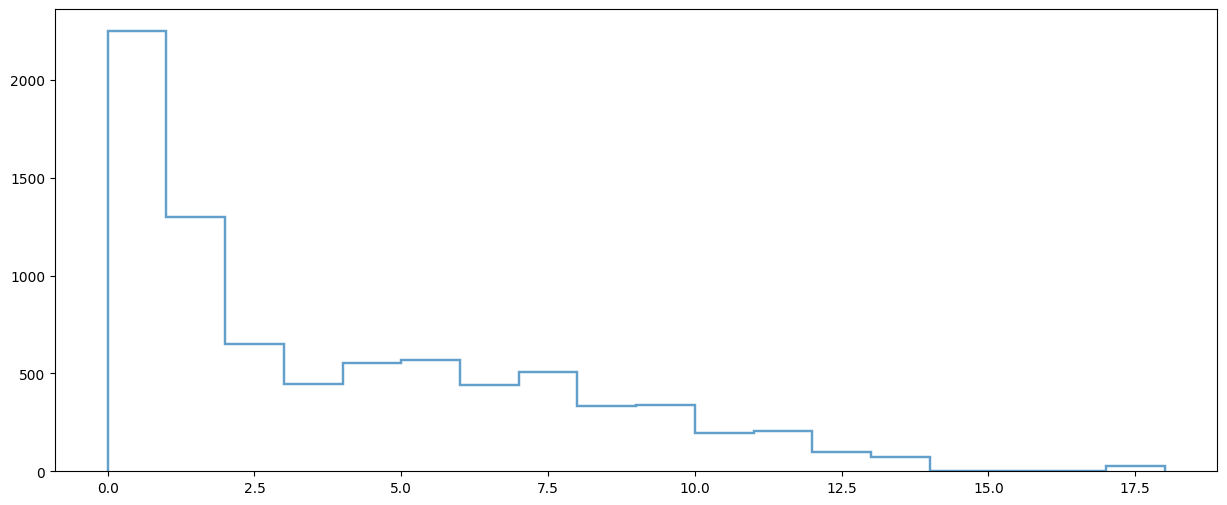

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define the colors for each opti_deadline
colors = ['blue', 'orange', 'green', 'red', 'purple']

# Prepare a list to store all differences
all_differences = []

# Loop through the files and read data
for i in range(1, 26):
    cost_file_path11 = f"outputs/pibt_scens_microsh4/cost1_{i}.txt"
    cost_file_path12 = f"outputs/pibt_scens_microsh4/cost20_{i}.txt"
    cost_file_path13 = f"outputs/pibt_scens_microsh4/cost21_{i}.txt"
    cost_file_path14 = f"outputs/pibt_scens_microsh4/cost22_{i}.txt"
    cost_file_path15 = f"outputs/pibt_scens_microsh4/cost23_{i}.txt"
    cost_file_path16 = f"outputs/pibt_scens_microsh4/cost24_{i}.txt"
    cost_file_path17 = f"outputs/pibt_scens_microsh4/cost25_{i}.txt"
    cost_file_path18 = f"outputs/pibt_scens_microsh4/cost26_{i}.txt"

    # Read costs from files
    with open(cost_file_path11, 'r') as file1:
        costs1 = list(map(int, file1.read().splitlines()))
    with open(cost_file_path12, 'r') as file2:
        costs2 = list(map(int, file2.read().splitlines()))
    with open(cost_file_path13, 'r') as file3:
        costs3 = list(map(int, file3.read().splitlines()))
    with open(cost_file_path14, 'r') as file4:
        costs4 = list(map(int, file4.read().splitlines()))
    with open(cost_file_path15, 'r') as file5:
        costs5 = list(map(int, file5.read().splitlines()))
    with open(cost_file_path16, 'r') as file6:
        costs6 = list(map(int, file6.read().splitlines()))
    with open(cost_file_path17, 'r') as file7:
        costs7 = list(map(int, file7.read().splitlines()))
    with open(cost_file_path18, 'r') as file8:
        costs8 = list(map(int, file8.read().splitlines()))

    # Create a DataFrame to filter out rows where all costs are zero
    cost_df = pd.DataFrame({
        'cost1': costs1,
        'cost2': costs2,
        'cost3': costs3,
        'cost4': costs4,
        'cost5': costs5,
        'cost6': costs6,
        'cost7': costs7,
        'cost8': costs8
    })

    # Remove rows where all values are 0
    cost_df = cost_df[(cost_df != 0).any(axis=1)]

    # Compute differences directly and store in all_differences
    all_differences.append(cost_df['cost1'] - cost_df['cost2'])  # For deadline 0
    all_differences.append(cost_df['cost1'] - cost_df['cost3'])  # For deadline 10
    all_differences.append(cost_df['cost1'] - cost_df['cost4'])  # For deadline 100
    all_differences.append(cost_df['cost1'] - cost_df['cost5'])  # For deadline 1000
    all_differences.append(cost_df['cost1'] - cost_df['cost6'])  # For deadline 10000
    all_differences.append(cost_df['cost1'] - cost_df['cost7'])  # For deadline 100000
    all_differences.append(cost_df['cost1'] - cost_df['cost8'])  # For deadline 1000000

# Prepare data for the histogram 
hist_data = [np.concatenate(all_differences[i::7]) for i in range(7)]
labels = [f"Deadline = {d}" for d in [0,0.01,0.1,1, 10, 100, 1000]]

# Define bins based on the combined data range
all_differences_combined = np.concatenate(hist_data)
bins = np.arange(0, 19)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(15, 6))

# Define distinct bar widths for each opti_deadline
# bar_widths = [0.9, 0.8, 0.7, 0.6, 0.5]

def bins_labels(bins, **kwargs):
    bin_w = 1
    plt.xticks(np.arange(0.5,19.5), bins, **kwargs)
    plt.xlim(bins[0], bins[-1])

# Plot each histogram on top of each other with different bar widths
for data, label in zip(reversed(hist_data), reversed(labels)):
    hist_values, bin_edges, = ax.hist(
        data, bins=bins, label=label, alpha=0.7, 
        align='mid', histtype='step', linewidth=1.75, rwidth=1
    )
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Add markers to the histogram
    plt.plot(bin_centers, hist_values, marker='o', linestyle='')

bins_labels(bins, fontsize=12)
# Add labels, legend, and title
ax.set_xlabel('F-Value Improvement')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.set_title('Histograms of F-Value Improvements by Anytime Deadline (milliseconds)')
ax.legend(loc='upper right')

# Display the plot
SMALL_SIZE = 18
MEDIUM_SIZE = 22
BIGGER_SIZE = 26

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.savefig("histogram.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()



In [ ]:
cost_file_path11 = f"outputs/pibt_scens_microsh5/cost1_{20}.txt"
cost_file_path18 = f"outputs/pibt_scens_microsh5/cost26_{20}.txt"

with open(cost_file_path11, 'r') as f1:
    cost1 = [float(line.strip()) for line in f1.readlines()]

with open(cost_file_path18, 'r') as f2:
    cost2 = [float(line.strip()) for line in f2.readlines()]

# Generate timesteps (assuming they start from 0 and are consecutive)
timesteps = list(range(len(cost1)))

# Plot Cost1 and Cost2 vs Timestep
plt.figure(figsize=(15, 6))
plt.plot(timesteps, cost1, label="Before Anytime PIBT", marker="o", markersize=5)
plt.plot(timesteps, cost2, label="After Anytime PIBT (1second timeout)", marker="o", markersize=5)

plt.xlabel("Timestep")
plt.ylabel("Normalized F-Value")
plt.title("Normalized F-Value (Before and After Anytime PIBT) vs Timestep")
plt.legend()
plt.grid(True)
# Display the plot
SMALL_SIZE = 18
MEDIUM_SIZE = 22
BIGGER_SIZE = 26

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.savefig("costs.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
csv_file_paths = [[csv_file_path3, csv_file_path31],
[csv_file_path6, csv_file_path61],
[csv_file_path9, csv_file_path91],
[csv_file_path12, csv_file_path121]]

for i, csv_list in enumerate(csv_file_paths):

    df2 = pd.read_csv(csv_list[0]) #lacam*
    df1 = pd.read_csv(csv_list[1])
    # Define the columns for matching agents,map_file,solver,solved
    matching_columns = ["agents", "map_file", "Scenario_File", "Opti_Deadline", "functype", "Bool_Opti"]

    # Replace rows in df2 with matching rows from df1
    merged_df = df2.copy()
    for _, row in df1.iterrows():
        mask = (df2[matching_columns] == row[matching_columns].values).all(axis=1)
        merged_df.loc[mask, :] = row.values

    # Save the updated DataFrame to a new CSV file
    merged_df.to_csv(f"merged_dataset_{i}.csv", index=False)

/tmp/ipykernel_805312/81513325.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sum_of_loss"] = df["sum_of_loss"] / df[columns[columns.index("sum_of_loss") + 1]]
/tmp/ipykernel_805312/81513325.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sum_of_loss"] = df["sum_of_loss"] / df[columns[columns.index("sum_of_loss") + 1]]
/tmp/ipykernel_805312/81513325.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = 

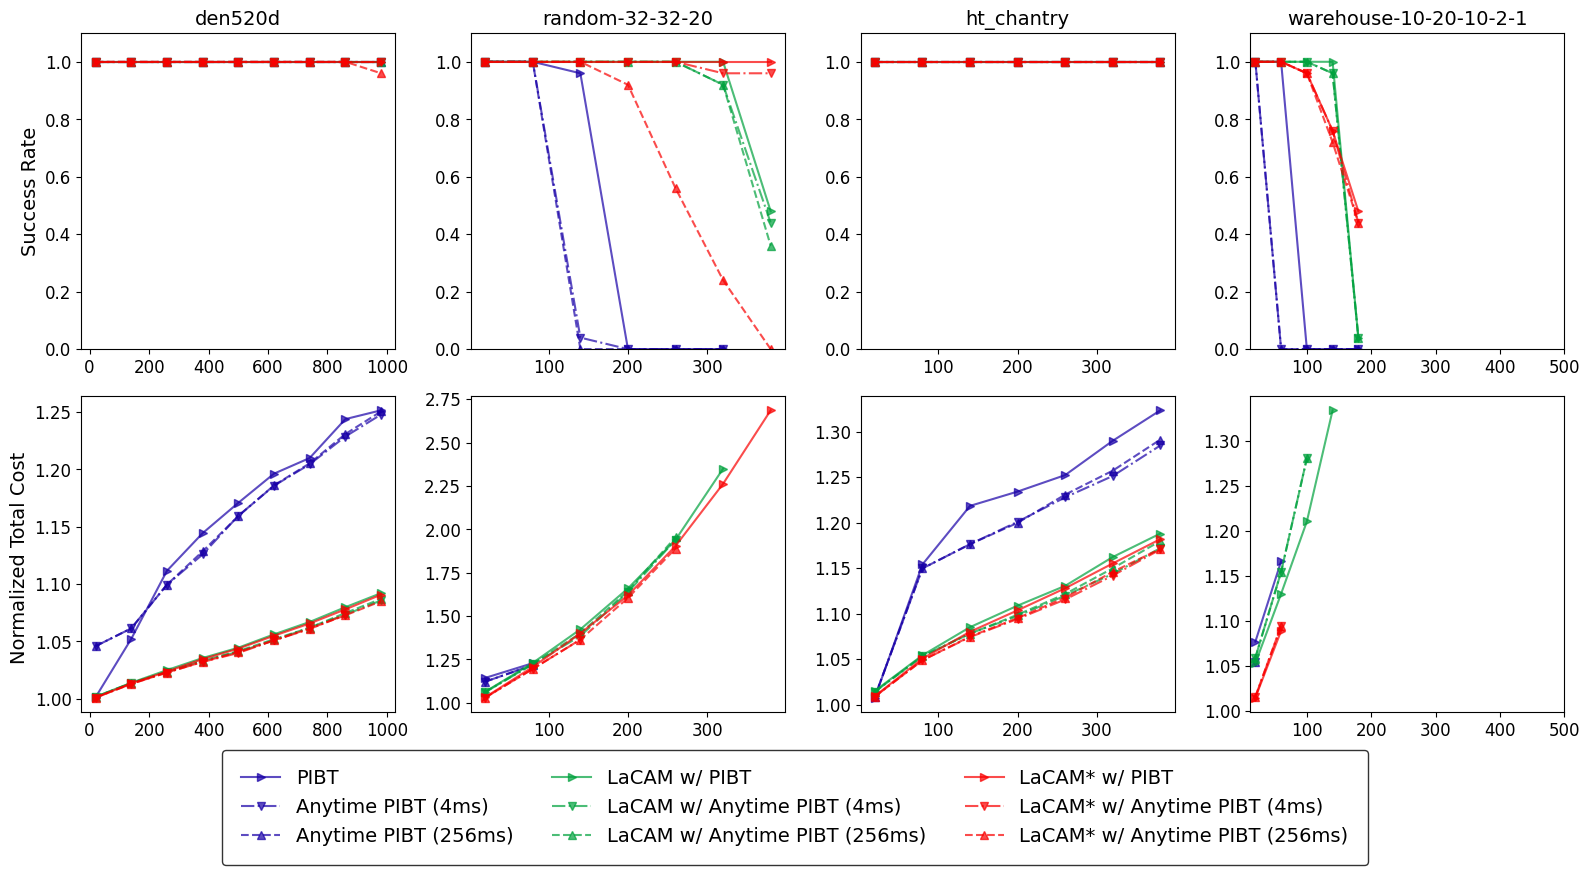

In [ ]:
# fig, axes = plt.subplots(3, 4, figsize=(12, 10))
ncols = 4
nrows = 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4,nrows*4))
datasets = ["den520d", "random-32-32-20", "ht_chantry", "warehouse-10-20-10-2-1"]
# datasets = ["random-32-32-20"]


cm = plt.get_cmap('nipy_spectral')
colors_map = [cm(1*i/7) for i in range(7)]
colors = [colors_map[1], colors_map[1], colors_map[1], colors_map[3], colors_map[3], colors_map[3], 
colors_map[6], colors_map[6], colors_map[6]]
linestyles = ['-', '-.', '--', '-', '-.', '--', '-', '-.', '--']
markers = [">", "v", "^"]

for i, csv_list in enumerate(csv_file_paths):
    csv_file_path1 = csv_list[0]
    csv_file_path2 = csv_list[1]
    csv_file_path3 = csv_list[2]

    df1 = pd.read_csv(csv_file_path1) #lacam + anytime pibt
    df2 = pd.read_csv(csv_file_path2) #vanilla v/s anytime pibt
    df2 = df2.rename(columns={"soc": "sum_of_loss"})
    df3 = pd.read_csv(csv_file_path3) #lacam*

    df11 = df1[df1["Bool_Opti"] == False]  #lacam + van pibt
    df12 = df1[(df1["Bool_Opti"] == True) & (df1["Opti_Deadline"] == 256)]  #lacam + anytime pibt (256ms)
    df13 = df1[(df1["Bool_Opti"] == True) & (df1["Opti_Deadline"] == 4)]  #lacam + anytime pibt (256ms)

    df21 = df2[df2["solver"] == "PIBTOLD"]  #vanilla pibt
    df22 = df2[(df2["solver"] == "PIBT") & (df2["Opti_Deadline"] == 256)]  #anytime pibt (256ms)
    df23 = df2[(df2["solver"] == "PIBT") & (df2["Opti_Deadline"] == 4)]  #lacam + anytime pibt (256ms)

    df31 = df3[df3["Bool_Opti"] == False]  #lacam* + van pibt + objective = 2
    df32 = df3[(df3["Bool_Opti"] == True) & (df3["Opti_Deadline"] == 256)]  #lacam* + anytime pibt (256ms) + objective = 2
    # df33 = df3[(df3["Bool_Opti"] == True) & (df3["Opti_Deadline"] == 64)]  #lacam* + anytime pibt (64) + objective = 2
    # df34 = df3[(df3["Bool_Opti"] == True) & (df3["Opti_Deadline"] == 16)]  #lacam* + anytime pibt (16) + objective = 2
    df35 = df3[(df3["Bool_Opti"] == True) & (df3["Opti_Deadline"] == 4)]  #lacam* + anytime pibt (256ms) + objective = 2
    # df36 = df3[(df3["Bool_Opti"] == True) & (df3["Opti_Deadline"] == 1)]  #lacam* + anytime pibt (256ms) + objective = 2
    # df37 = df3[(df3["Bool_Opti"] == True) & (df3[ "Opti_Deadline"] == 0)]  #lacam* + anytime pibt (256ms) + objective = 2

    #  
    # "Lacam* + Anytime PIBT (0ms) + Objective = 2""Lacam* + Anytime PIBT (1ms) + Objective = 2", 
            #   "Lacam* + Anytime PIBT (0ms) + Objective = 2" df33,df34, df36, df37
    legend = ["PIBT", "Anytime PIBT (4ms)","Anytime PIBT (256ms)", 
        "LaCAM w/ PIBT", "LaCAM w/ Anytime PIBT (4ms)","LaCAM w/ Anytime PIBT (256ms)", 
              "LaCAM* w/ PIBT",  "LaCAM* w/ Anytime PIBT (4ms)", "LaCAM* w/ Anytime PIBT (256ms)"]

    ax1 = axes[0, i]
    # 
    for j, df in enumerate([df21, df23, df22, df11, df13, df12, df31, df35,
    df32]):
        if "agents" in df.columns and "solved" in df.columns:
            # grouped = df.groupby("agents")["solved"].mean()
            grouped = df.groupby("agents")["solved"].sum().clip(upper=25) / 25
            ax1.plot(grouped.index, grouped.values, color=colors[j], linestyle = linestyles[j], marker=markers[j%3], alpha=0.7)
            ax1.set_ylim([0.0, 1.1])

            ax1.set_title(datasets[i], fontsize=14)
            ax1.tick_params(axis='both', which='major', labelsize=12)
            # ax1.set_xlabel("Agents")
    axes[0, 0].set_ylabel("Success Rate", fontsize=14)

    ax1 = axes[1, i]
    # df11, df12, df21, df22, 
    for j, df in enumerate([df21, df22, df23, df11, df12, df13, df31, df32,
    df35]):
        if "agents" in df.columns and "sum_of_loss" in df.columns:
            grouped_success = df.groupby("agents")["solved"].sum().clip(upper=25) / 25
            valid_agents = grouped_success[grouped_success == 1.0].index  # Only agents with success rate > 60%
            
            # Filter the DataFrame to only include valid agents
            df = df[df['agents'].isin(valid_agents)]
            columns = df.columns.to_list()
            df["sum_of_loss"] = df["sum_of_loss"] / df[columns[columns.index("sum_of_loss") + 1]]
            grouped = df.groupby("agents")["sum_of_loss"].mean()
            ax1.plot(grouped.index, grouped.values, color=colors[j], linestyle = linestyles[j], marker=markers[j%3], alpha=0.7)
            ax1.tick_params(axis='both', which='major', labelsize=12)
            # ax1.set_yscale("log")
            # ax1.set_ylim([0, 150])

            # ax1.set_title(datasets[i])
            # ax1.set_xlabel("Agents")
    axes[1, 0].set_ylabel("Normalized Total Cost ", fontsize=14)

    # ax1 = axes[2, i]
    # df11, df12, df21, df22, 
    # for j, df in enumerate([df21, df22, df23, df11, df12, df13, df31, df32,
    # df35]):
    #     if "agents" in df.columns and "makespan" in df.columns:
    #         valid_agents = df.groupby('agents')['solved'].all()
    #         valid_agents = valid_agents[valid_agents == True].index
            
    #         # Filter the DataFrame to only include valid agents
    #         df = df[df['agents'].isin(valid_agents)]
    #         columns = df.columns.to_list()
    #         df["makespan"] = df["makespan"] / df[columns[columns.index("makespan") + 1]]
    #         grouped = df.groupby("agents")["makespan"].mean()
    #         ax1.plot(grouped.index, grouped.values, color=colors[j], linestyle = linestyles[j], marker=markers[j%3], alpha=0.7)
    #         ax1.tick_params(axis='both', which='major', labelsize=12)
    #         # ax1.set_ylim([0.0, 1.1])

    #         # ax1.set_title(datasets[i])
    #         ax1.set_xlabel("Agents", fontsize=14)
    #         # ax1.set_yscale("log")
    # axes[2, 0].set_ylabel("Normalized Makespan", fontsize=14)

axes[0, 3].set_xlim(right=500)
for i in range(4):
    x_limits = axes[0, i].get_xlim()
    x_ticks = axes[0, i].get_xticks()
    axes[1, i].set_xlim(x_limits)
    # axes[1, i].set_xticks(x_ticks[1:-1])

fig.legend(legend, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.15), frameon=True,
fontsize=14, fancybox=True, edgecolor='black', borderpad=1)
plt.tight_layout(rect=[0, 0, 1, 0.95])
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=14)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.savefig("12x3plot.png", dpi=300, bbox_inches="tight")


/tmp/ipykernel_891313/1084071252.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sum_of_loss"] /= df[df.columns[df.columns.get_loc("sum_of_loss") + 1]]
/tmp/ipykernel_891313/1084071252.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sum_of_loss"] /= df[df.columns[df.columns.get_loc("sum_of_loss") + 1]]
/tmp/ipykernel_891313/1084071252.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

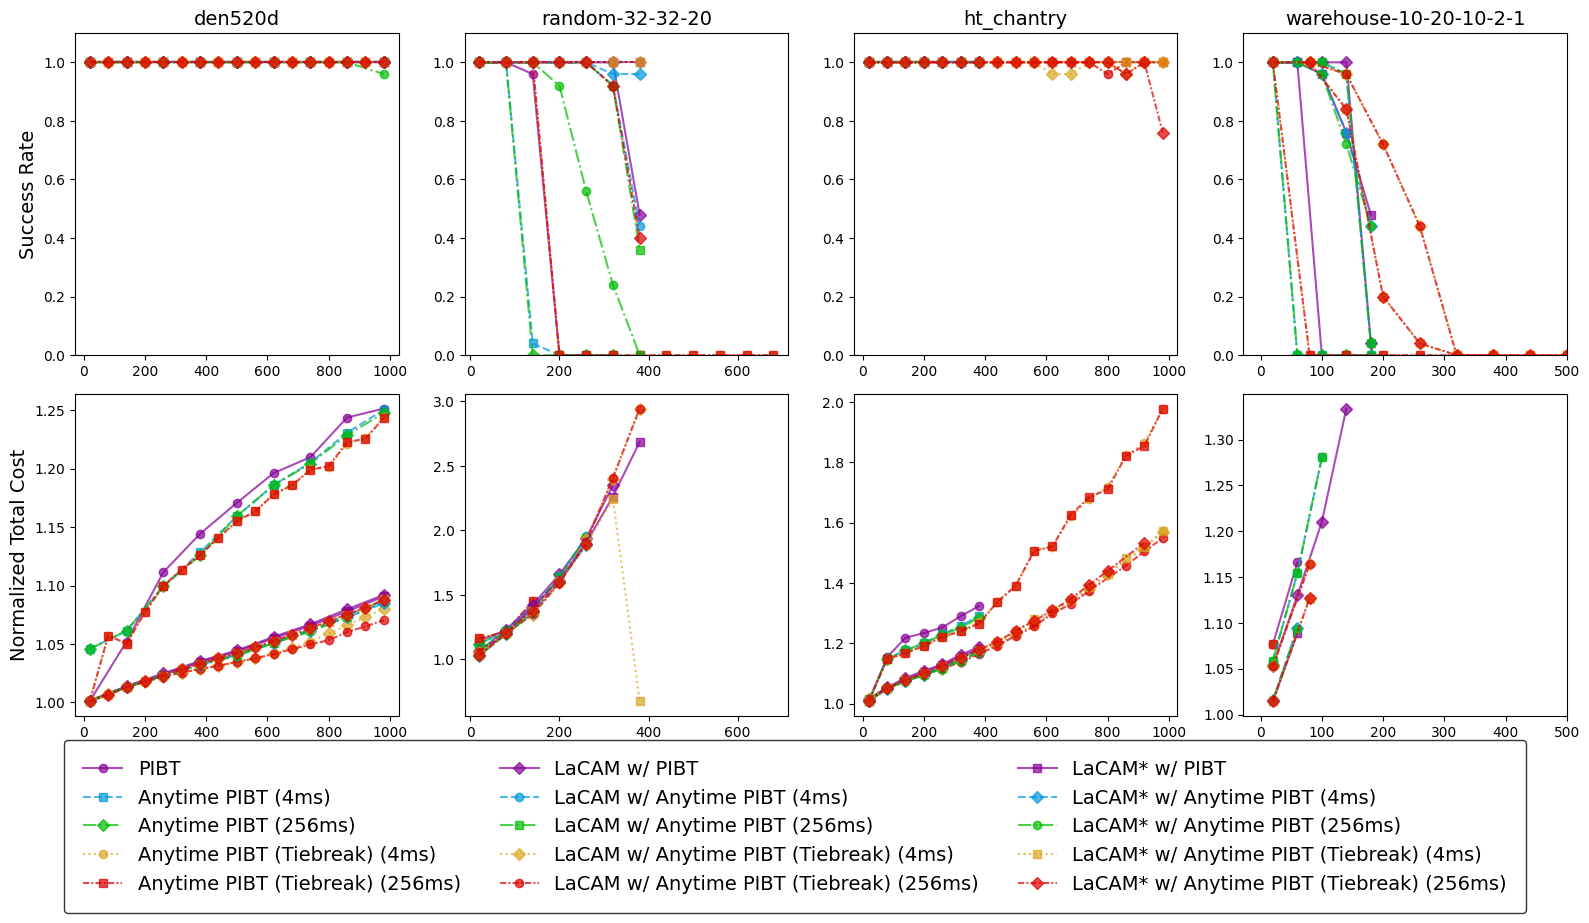

In [ ]:
ncols, nrows = 4, 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*4))
datasets = ["den520d", "random-32-32-20", "ht_chantry", "warehouse-10-20-10-2-1"]

cm = plt.get_cmap('nipy_spectral')
colors_map = [cm(i/10) for i in range(10)]
colors = [colors_map[i] for i in [1, 3, 5, 7, 9]*3]
colors = [
    colors_map[1],  # PIBT (Purple)
    colors_map[3],  # Anytime PIBT (4ms) (Blue)
    colors_map[5],  # Anytime PIBT (256ms) (Green)
    "#DAA520",      # Darker Yellow for Anytime PIBT (Tiebreak) (4ms)
    colors_map[9],  # Anytime PIBT (Tiebreak) (256ms) (Red)
] * 3  # Repeat for PIBT, LaCAM, and LaCAM*
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))] * 3  # 5 styles * 3 groups
markers = ['o', 's', 'D', '^', 'v'] * 3  # 5 markers * 3 groups

legend = [
    "PIBT", "Anytime PIBT (4ms)", "Anytime PIBT (256ms)", "Anytime PIBT (Tiebreak) (4ms)", "Anytime PIBT (Tiebreak) (256ms)",
    "LaCAM w/ PIBT", "LaCAM w/ Anytime PIBT (4ms)", "LaCAM w/ Anytime PIBT (256ms)", "LaCAM w/ Anytime PIBT (Tiebreak) (4ms)", "LaCAM w/ Anytime PIBT (Tiebreak) (256ms)",
    "LaCAM* w/ PIBT", "LaCAM* w/ Anytime PIBT (4ms)", "LaCAM* w/ Anytime PIBT (256ms)", "LaCAM* w/ Anytime PIBT (Tiebreak) (4ms)", "LaCAM* w/ Anytime PIBT (Tiebreak) (256ms)"
]

for i, csv_list in enumerate(csv_file_paths):
    dataframes = [pd.read_csv(csv) for csv in csv_list]
    df1, df2, df3, df1t, df2t, df3t = dataframes

    for df in [df1, df1t, df3, df3t]:
        df = df[df["N"] == df["agents"]]  # Keep only rows where N matches agents
    
    df2 = df2.rename(columns={"soc": "sum_of_loss"})
    df2t = df2t.rename(columns={"soc": "sum_of_loss"})
    
    # Define Data Subsets
    subsets = [
        df2[df2["solver"] == "PIBTOLD"],  # PIBT
        df2[(df2["solver"] == "PIBT") & (df2["Opti_Deadline"] == 4)],  # Anytime PIBT (4ms)
        df2[(df2["solver"] == "PIBT") & (df2["Opti_Deadline"] == 256)],  # Anytime PIBT (256ms)
        df2t[(df2t["solver"] == "PIBT") & (df2t["Opti_Deadline"] == 4)],  # Anytime PIBT Tiebreak (4ms)
        df2t[(df2t["solver"] == "PIBT") & (df2t["Opti_Deadline"] == 256)],  # Anytime PIBT Tiebreak (256ms)
        
        df1[df1["Bool_Opti"] == False],  # LaCAM w/ PIBT
        df1[(df1["Bool_Opti"] == True) & (df1["Opti_Deadline"] == 4)],  # LaCAM w/ Anytime PIBT (4ms)
        df1[(df1["Bool_Opti"] == True) & (df1["Opti_Deadline"] == 256)],  # LaCAM w/ Anytime PIBT (256ms)
        df1t[(df1t["Bool_Opti"] == True) & (df1t["Opti_Deadline"] == 4)],  # LaCAM w/ Anytime PIBT Tiebreak (4ms)
        df1t[(df1t["Bool_Opti"] == True) & (df1t["Opti_Deadline"] == 256)],  # LaCAM w/ Anytime PIBT Tiebreak (256ms)
        
        df3[df3["Bool_Opti"] == False],  # LaCAM* w/ PIBT
        df3[(df3["Bool_Opti"] == True) & (df3["Opti_Deadline"] == 4)],  # LaCAM* w/ Anytime PIBT (4ms)
        df3[(df3["Bool_Opti"] == True) & (df3["Opti_Deadline"] == 256)],  # LaCAM* w/ Anytime PIBT (256ms)
        df3t[(df3t["Bool_Opti"] == True) & (df3t["Opti_Deadline"] == 4)],  # LaCAM* w/ Anytime PIBT Tiebreak (4ms)
        df3t[(df3t["Bool_Opti"] == True) & (df3t["Opti_Deadline"] == 256)]  # LaCAM* w/ Anytime PIBT Tiebreak (256ms)
    ]
    
    # Success Rate Plot
    ax1 = axes[0, i]
    for j, df in enumerate(subsets):
        if "agents" in df.columns and "solved" in df.columns:
            grouped = df.groupby("agents")["solved"].sum().clip(upper=25) / 25
            ax1.plot(grouped.index, grouped.values, color=colors[j], linestyle=linestyles[j%5], marker=markers[j%3], alpha=0.7)
    ax1.set_ylim([0.0, 1.1])
    ax1.set_title(datasets[i], fontsize=14)
    
    # Normalized Total Cost Plot
    ax2 = axes[1, i]
    for j, df in enumerate(subsets):
        if "agents" in df.columns and "sum_of_loss" in df.columns:
            grouped_success = df.groupby("agents")["solved"].sum().clip(upper=25) / 25
            valid_agents = grouped_success[grouped_success == 1.0].index
            df = df[df['agents'].isin(valid_agents)]
            df["sum_of_loss"] /= df[df.columns[df.columns.get_loc("sum_of_loss") + 1]]
            grouped = df.groupby("agents")["sum_of_loss"].mean()
            ax2.plot(grouped.index, grouped.values, color=colors[j], linestyle=linestyles[j%5], marker=markers[j%3], alpha=0.7)

axes[0, 3].set_xlim(right=500)
for i in range(4):
    x_limits = axes[0, i].get_xlim()
    x_ticks = axes[0, i].get_xticks()
    axes[1, i].set_xlim(x_limits)

axes[0, 0].set_ylabel("Success Rate", fontsize=14)
axes[1, 0].set_ylabel("Normalized Total Cost", fontsize=14)
axes[0, 3].set_xlim(right=500)

fig.legend(legend, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.21), frameon=True, fontsize=14, fancybox=True, edgecolor='black', borderpad=1)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("12x3plot.png", dpi=300, bbox_inches="tight")


/tmp/ipykernel_891313/2620037758.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sum_of_loss"] /= df[df.columns[df.columns.get_loc("sum_of_loss") + 1]]
/tmp/ipykernel_891313/2620037758.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sum_of_loss"] /= df[df.columns[df.columns.get_loc("sum_of_loss") + 1]]
/tmp/ipykernel_891313/2620037758.py:76: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

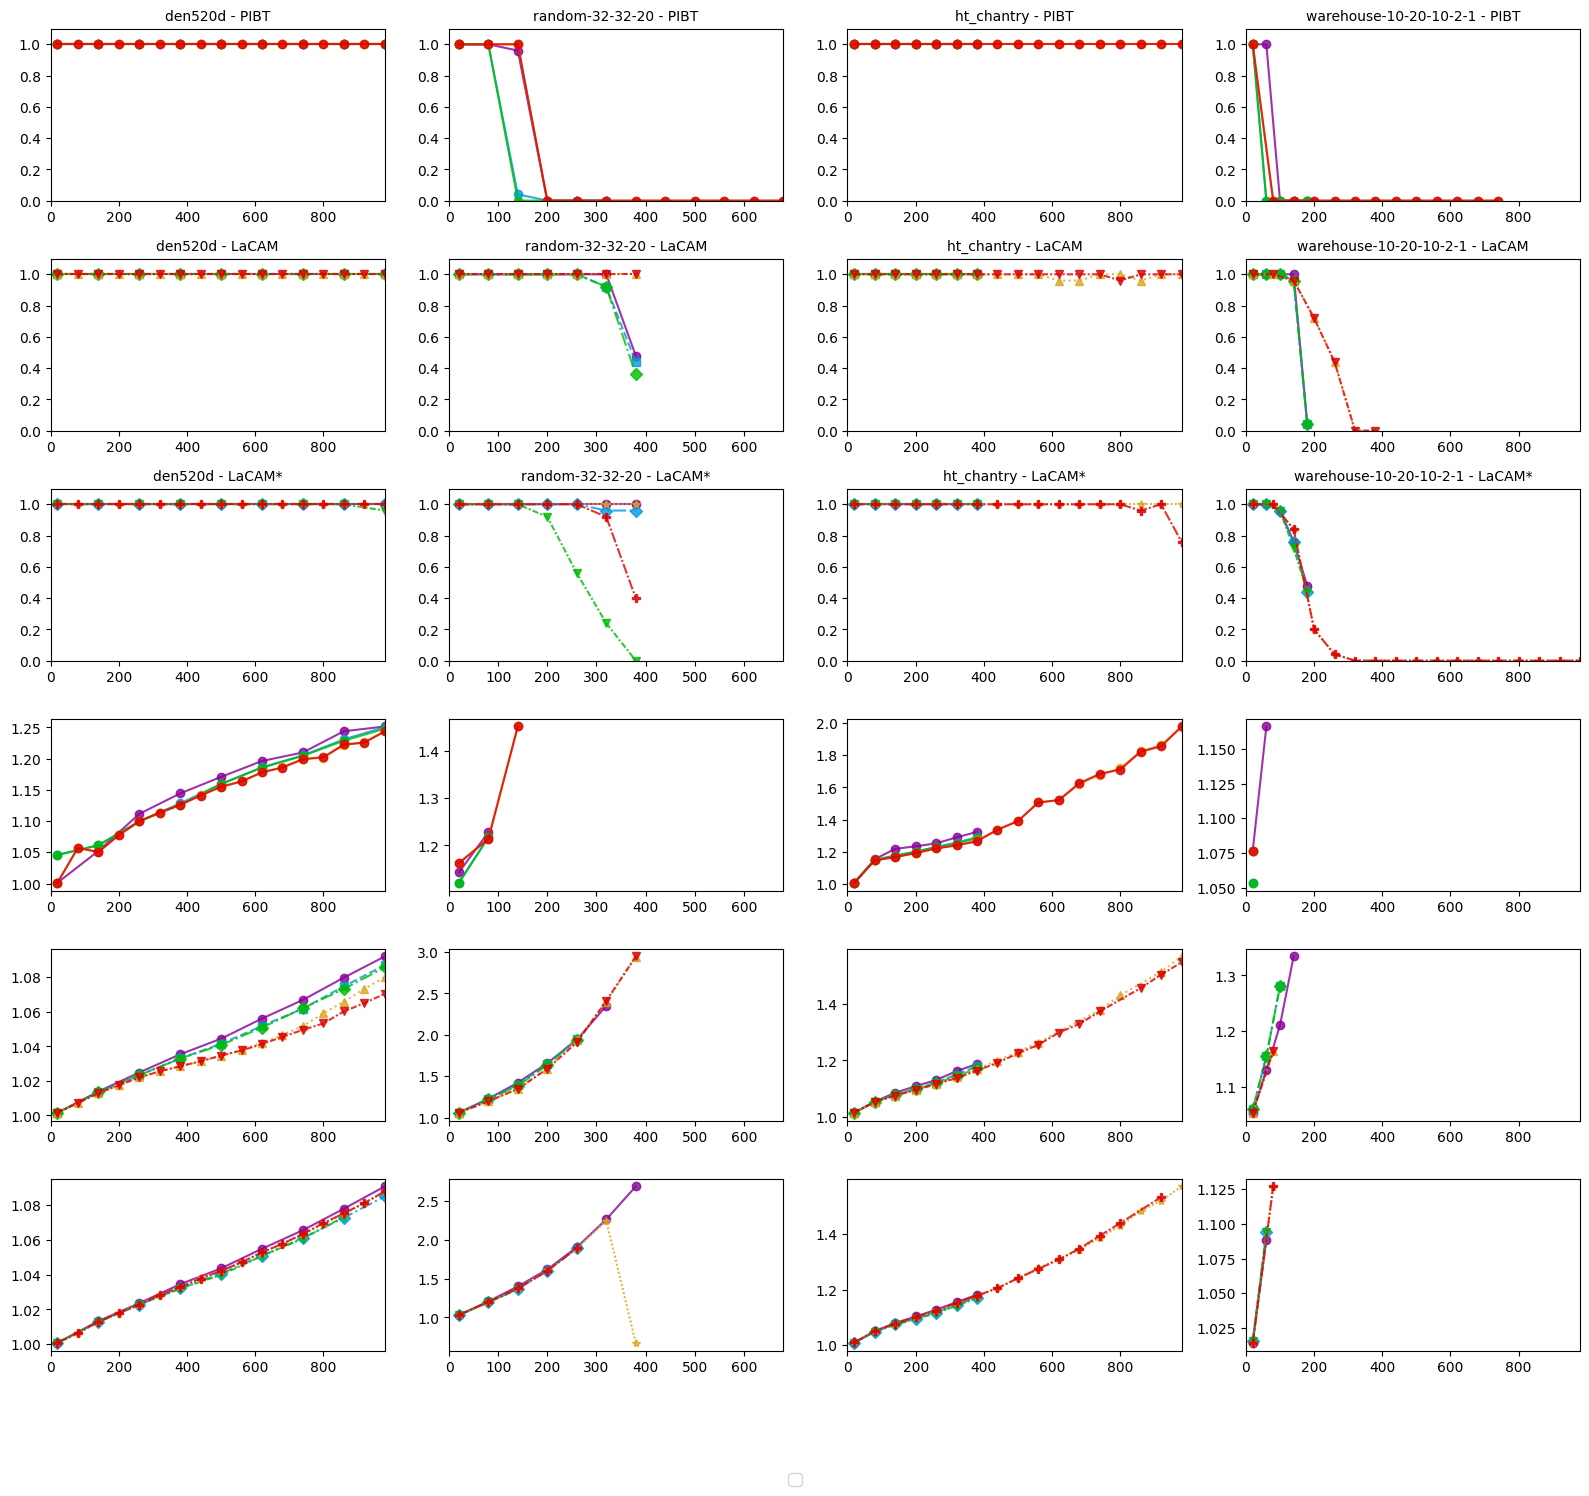

In [ ]:
ncols, nrows = 4, 6  # 4 datasets, 6 rows (3 Success Rate + 3 Normalized Cost)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 2.5))
datasets = ["den520d", "random-32-32-20", "ht_chantry", "warehouse-10-20-10-2-1"]

cm = plt.get_cmap('nipy_spectral')
colors_map = [cm(i / 10) for i in range(10)]
colors = [
    colors_map[1], colors_map[3], colors_map[5], "#DAA520", colors_map[9],  # PIBT Variants
    colors_map[1], colors_map[3], colors_map[5], "#DAA520", colors_map[9],  # LaCAM Variants
    colors_map[1], colors_map[3], colors_map[5], "#DAA520", colors_map[9],  # LaCAM* Variants
]

markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X', 'P', 'H', '8', '<', '>', '|', '_']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), 
              (0, (5, 2)), (0, (1, 1)), (0, (3, 2, 1, 2)), (0, (5, 1, 1, 1)), 
              (0, (4, 3, 1, 3)), (0, (6, 1)), (0, (2, 1, 2, 1)), 
              (0, (3, 3, 1, 3)), (0, (1, 2, 1, 2)), (0, (2, 2, 2, 2))]

x_lims_per_column = [0] * ncols  # Store max x-limits for each dataset

legend = [
    "PIBT", "Anytime PIBT (4ms)", "Anytime PIBT (256ms)", "Anytime PIBT (Tiebreak) (4ms)", "Anytime PIBT (Tiebreak) (256ms)",
    "LaCAM w/ PIBT", "LaCAM w/ Anytime PIBT (4ms)", "LaCAM w/ Anytime PIBT (256ms)", "LaCAM w/ Anytime PIBT (Tiebreak) (4ms)", "LaCAM w/ Anytime PIBT (Tiebreak) (256ms)",
    "LaCAM* w/ PIBT", "LaCAM* w/ Anytime PIBT (4ms)", "LaCAM* w/ Anytime PIBT (256ms)", "LaCAM* w/ Anytime PIBT (Tiebreak) (4ms)", "LaCAM* w/ Anytime PIBT (Tiebreak) (256ms)"
]

for i, csv_list in enumerate(csv_file_paths):
    dataframes = [pd.read_csv(csv) for csv in csv_list]
    df1, df2, df3, df1t, df2t, df3t = dataframes

    for df in [df1, df1t, df3, df3t]:
        df = df[df["N"] == df["agents"]]

    df2 = df2.rename(columns={"soc": "sum_of_loss"})
    df2t = df2t.rename(columns={"soc": "sum_of_loss"})

    # Data Subsets
    subsets = [
        df2[df2["solver"] == "PIBTOLD"],  
        df2[(df2["solver"] == "PIBT") & (df2["Opti_Deadline"] == 4)],
        df2[(df2["solver"] == "PIBT") & (df2["Opti_Deadline"] == 256)],
        df2t[(df2t["solver"] == "PIBT") & (df2t["Opti_Deadline"] == 4)],
        df2t[(df2t["solver"] == "PIBT") & (df2t["Opti_Deadline"] == 256)]
    ]

    lacam_subsets = [
        df1[df1["Bool_Opti"] == False],
        df1[(df1["Bool_Opti"] == True) & (df1["Opti_Deadline"] == 4)],
        df1[(df1["Bool_Opti"] == True) & (df1["Opti_Deadline"] == 256)],
        df1t[(df1t["Bool_Opti"] == True) & (df1t["Opti_Deadline"] == 4)],
        df1t[(df1t["Bool_Opti"] == True) & (df1t["Opti_Deadline"] == 256)]
    ]

    lacam_star_subsets = [
        df3[df3["Bool_Opti"] == False],
        df3[(df3["Bool_Opti"] == True) & (df3["Opti_Deadline"] == 4)],
        df3[(df3["Bool_Opti"] == True) & (df3["Opti_Deadline"] == 256)],
        df3t[(df3t["Bool_Opti"] == True) & (df3t["Opti_Deadline"] == 4)],
        df3t[(df3t["Bool_Opti"] == True) & (df3t["Opti_Deadline"] == 256)]
    ]

    all_variants = [subsets, lacam_subsets, lacam_star_subsets]

    for row, variant in enumerate(all_variants):
        ax = axes[row, i]  # Success Rate
        for j, df in enumerate(variant):
            if "agents" in df.columns and "solved" in df.columns:
                grouped = df.groupby("agents")["solved"].sum().clip(upper=25) / 25
                ax.plot(grouped.index, grouped.values, color=colors[j], linestyle=linestyles[j*row], marker=markers[j*row], alpha=0.8, markersize=6, label=legend[j])
                x_lims_per_column[i] = max(x_lims_per_column[i], grouped.index.max())

        ax.set_ylim([0.0, 1.1])
        ax.set_title(f"{datasets[i]} - {'PIBT' if row == 0 else 'LaCAM' if row == 1 else 'LaCAM*'}", fontsize=10)

    for row, variant in enumerate(all_variants):
        ax = axes[row+3, i]  # Normalized Cost
        for j, df in enumerate(variant):
            if "agents" in df.columns and "sum_of_loss" in df.columns:
                grouped_success = df.groupby("agents")["solved"].sum().clip(upper=25) / 25
                valid_agents = grouped_success[grouped_success == 1.0].index
                df = df[df['agents'].isin(valid_agents)]
                df["sum_of_loss"] /= df[df.columns[df.columns.get_loc("sum_of_loss") + 1]]
                grouped = df.groupby("agents")["sum_of_loss"].mean()
                ax.plot(grouped.index, grouped.values, color=colors[j], linestyle=linestyles[j*row], marker=markers[j*row], alpha=0.8, markersize=6)
                x_lims_per_column[i] = max(x_lims_per_column[i], grouped.index.max())

# Normalize x-axis limits for each column
for col in range(ncols):
    x_limit = x_lims_per_column[col]
    for row in range(nrows):
        axes[row, col].set_xlim(0, x_limit)

handles, labels = axes[0, 0].get_legend_handles_labels()  # Get line objects and labels dynamically
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.07), frameon=True, fontsize=12)
# fig.legend(legend, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.07), frameon=True, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("6x4_plot.png", dpi=300, bbox_inches="tight")


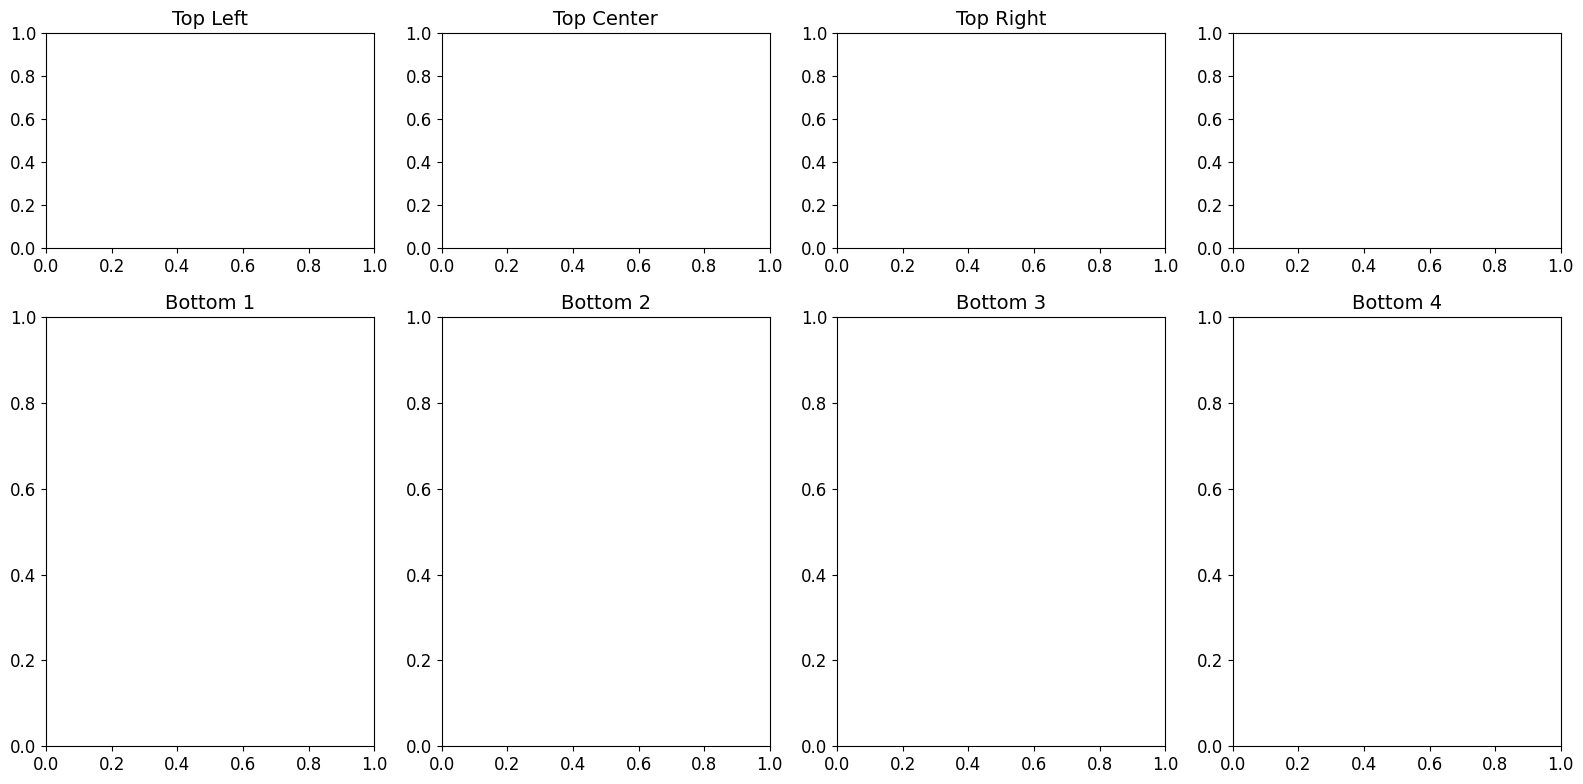

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Define the overall figure and grid
fig = plt.figure(figsize=(4 * 4, 2 * 4))  # Adjust the size as needed
gs = gridspec.GridSpec(2, 4, height_ratios=[0.5, 1])  # First row taller than the second

# Create subplots in the first row (3 subplots inside one)
gs_top = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0, :])

ax_top1 = fig.add_subplot(gs_top[0, 0])
ax_top2 = fig.add_subplot(gs_top[0, 1])
ax_top3 = fig.add_subplot(gs_top[0, 2])
ax_top4 = fig.add_subplot(gs_top[0, 3])

# Create subplots in the second row (4 individual subplots)
ax_bottom1 = fig.add_subplot(gs[1, 0])
ax_bottom2 = fig.add_subplot(gs[1, 1])
ax_bottom3 = fig.add_subplot(gs[1, 2])
ax_bottom4 = fig.add_subplot(gs[1, 3])

# Example: setting titles for clarity
ax_top1.set_title("Top Left")
ax_top2.set_title("Top Center")
ax_top3.set_title("Top Right")

ax_bottom1.set_title("Bottom 1")
ax_bottom2.set_title("Bottom 2")
ax_bottom3.set_title("Bottom 3")
ax_bottom4.set_title("Bottom 4")

plt.tight_layout()
plt.show()


In [ ]:
# Initialize a list to hold the maximum agent count for datasets with success rate > 70%
highest_agents = []

for i, csv_list in enumerate(csv_file_paths):
    csv_file_path1 = csv_list[0]
    csv_file_path2 = csv_list[1]
    csv_file_path3 = csv_list[2]

    # Load CSVs
    df1 = pd.read_csv(csv_file_path1)  # lacam + anytime pibt
    df2 = pd.read_csv(csv_file_path2)  # vanilla v/s anytime pibt
    df3 = pd.read_csv(csv_file_path3)  # lacam*

    # Find unique agent counts in each dataset
    agent_counts1 = df1['agents'].unique()
    agent_counts2 = df2['agents'].unique()
    agent_counts3 = df3['agents'].unique()

    # Initialize variables to store the highest agent count with success rate > 70%
    highest_agent1 = None
    highest_agent2 = None
    highest_agent3 = None

    # Iterate over unique agent counts in df1 and calculate success rate
    for agents in agent_counts1:
        df_subset1 = df1[df1["agents"] == agents]
        success_rate1 = df_subset1.groupby("Opti_Deadline")["solved"].mean().mean()
        if success_rate1 > 0.7:
            highest_agent1 = agents  # Update if this agent count has success rate > 70%

    # Iterate over unique agent counts in df2 and calculate success rate
    for agents in agent_counts2:
        df_subset2 = df2[df2["agents"] == agents]
        success_rate2 = df_subset2.groupby("Opti_Deadline")["solved"].mean().mean()
        if success_rate2 > 0.7:
            highest_agent2 = agents  # Update if this agent count has success rate > 70%

    # Iterate over unique agent counts in df3 and calculate success rate
    for agents in agent_counts3:
        df_subset3 = df3[df3["agents"] == agents]
        success_rate3 = df_subset3.groupby("Opti_Deadline")["solved"].mean().mean()
        if success_rate3 > 0.7:
            highest_agent3 = agents  # Update if this agent count has success rate > 70%

    # Append the highest agent counts with success rate > 70%
    if highest_agent1 is not None:
        highest_agents.append(highest_agent1)

    if highest_agent2 is not None:
        highest_agents.append(highest_agent2)

    if highest_agent3 is not None:
        highest_agents.append(highest_agent3)

# Now `highest_agents` will contain the maximum agent count for datasets with a success rate > 70%
print(highest_agents)


In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(4*4,3*4))

cm = plt.get_cmap('nipy_spectral')
colors_map = [cm(1*i/7) for i in range(7)]
colors = [colors_map[1], colors_map[1], colors_map[3], colors_map[3], 
colors_map[6], colors_map[6]]
linestyles = ['-', '-', '-', '-', '-', '-']
markers = [">", "v"]

datasets = ["den520d: 980 agents", "random-32-32-20: 80 agents", "ht_chantry: 380 agents", "warehouse-10-20-10-2-1: 140 agents"]
max_agents = [980, 80, 380, 140]

# legend = ["PIBT", "Anytime PIBT (256ms)", "Anytime PIBT (4ms)",
#         "LaCAM w/ PIBT", "LaCAM w/ Anytime PIBT (256ms)", "LaCAM w/ Anytime PIBT (4ms)",
#               "LaCAM* w/ PIBT", "LaCAM* w/ Anytime PIBT (256ms)",
#               "LaCAM* w/ Anytime PIBT (4ms)"]

legend = ["PIBT", "Anytime PIBT", 
    "Lacam + PIBT", "Lacam + Anytime PIBT",
              "Lacam* + PIBT", "Lacam* + Anytime PIBT"]

for i, csv_list in enumerate(csv_file_paths):
    csv_file_path1 = csv_list[0]
    csv_file_path2 = csv_list[1]
    csv_file_path3 = csv_list[2]

    df1 = pd.read_csv(csv_file_path1) #lacam + anytime pibt
    df1 = df1[df1["agents"] == max_agents[i]]

    df2 = pd.read_csv(csv_file_path2) #vanilla v/s anytime pibt
    # df2 = df2[df2["solved"] == 1]
    df2 = df2[df2["agents"] == max_agents[i]]
    df2 = df2.rename(columns={"soc": "sum_of_loss"})
    df2 = df2.rename(columns={"lb_soc": "sum_of_loss_lb"})
    df2 = df2.rename(columns={"lb_makespan": "makespan_lb"})

    df3 = pd.read_csv(csv_file_path3) #lacam*
    # df3 = df3[df3["solved"] == 1]
    df3 = df3[df3["agents"] == max_agents[i]]

    df11 = df1[df1["Bool_Opti"] == False]  #lacam + van pibt
    df11 = df11[df11["solved"] == 1]
    df12 = df1[(df1["Bool_Opti"] == True)]  #lacam + anytime pibt

    df21 = df2[df2["solver"] == "PIBTOLD"]  #vanilla pibt
    df21 = df21[df21["solved"] == 1]
    df22 = df2[(df2["solver"] == "PIBT")]  #anytime pibt (256ms)
    
    df31 = df3[df3["Bool_Opti"] == False]  #lacam* + van pibt + objective = 2
    df31 = df31[df31["solved"] == 1]
    df32 = df3[(df3["Bool_Opti"] == True)]  #lacam* + anytime pibt ( + objective = 2

    ax1 = axes[0, i]
    for j, df in enumerate([df21, df22, df11, df12, df31, df32]):
        if "Opti_Deadline" in df.columns and "solved" in df.columns:
            grouped = df.groupby("Opti_Deadline")["solved"].mean()
            ax1.plot(grouped.index, grouped.values, color=colors[j], linestyle = linestyles[j], marker=markers[j%2])
            ax1.set_ylim([0.0, 1.1])

            ax1.set_title(datasets[i])
            ax1.tick_params(axis='both', which='major', labelsize=12)
            # ax1.set_xlabel("Agents")
            ax1.set_xscale('symlog', base=4)
    axes[0, 0].set_ylabel("Success Rate", fontsize=14)

    ax1 = axes[1, i]
    for j, df in enumerate([df21, df22, df11, df12, df31, df32]):
        df = df[df["solved"] == 1]
    # df = df11
        if "Opti_Deadline" in df.columns and "sum_of_loss" in df.columns:
            
            df_backup = df

            if df_backup.equals(df11) or df_backup.equals(df21) or df_backup.equals(df31):
                continue

            valid_agents = df.groupby('Opti_Deadline')['solved'].all()
            valid_agents = valid_agents[valid_agents == True].index
            
            # Filter the DataFrame to only include valid agents
            df = df[df['Opti_Deadline'].isin(valid_agents)]
            columns = df.columns.to_list()
            df["sum_of_loss"] = df["sum_of_loss"] / df[columns[columns.index("sum_of_loss") + 1]]
            grouped = df.groupby("Opti_Deadline")["sum_of_loss"].mean()
            line, = ax1.plot(grouped.index, grouped.values, color=colors[j], linestyle = linestyles[j], marker=markers[j%2])
            ax1.set_xscale('symlog', base=4)
            ax1.tick_params(axis='both', which='major', labelsize=12)
                
    axes[1, 0].set_ylabel("Normalized Sum of Loss", fontsize=14)
    axes[1, i].axhline((df11["sum_of_loss"] / df11["sum_of_loss_lb"]).mean(), color=colors[3], linestyle='--', linewidth=1.5)
    axes[1, i].axhline((df31["sum_of_loss"] / df31["sum_of_loss_lb"]).mean(), color=colors[5], linestyle='--', linewidth=1.5)
    axes[1, i].axhline((df21["sum_of_loss"] / df21["sum_of_loss_lb"]).mean(), color=colors[1], linestyle='--', linewidth=1.5)

    ax1 = axes[2, i]
    for j, df in enumerate([df21, df22, df11, df12, df31, df32]):
        df = df[df["solved"] == 1]
    # df = df11
        if "Opti_Deadline" in df.columns and "makespan" in df.columns:
            
            df_backup = df

            if df_backup.equals(df11) or df_backup.equals(df21) or df_backup.equals(df31):
                continue

            valid_agents = df.groupby('Opti_Deadline')['solved'].all()
            valid_agents = valid_agents[valid_agents == True].index
            
            # Filter the DataFrame to only include valid agents
            df = df[df['Opti_Deadline'].isin(valid_agents)]
            columns = df.columns.to_list()
            df["makespan"] = df["makespan"] / df[columns[columns.index("makespan") + 1]]
            grouped = df.groupby("Opti_Deadline")["makespan"].mean()
            line, = ax1.plot(grouped.index, grouped.values, color=colors[j], linestyle = linestyles[j], marker=markers[j%2])
            ax1.set_xscale('symlog', base=4)
            ax1.tick_params(axis='both', which='major', labelsize=12)
            ax1.set_xlabel("Anytime Timeout (ms)", fontsize=14)
                
    axes[2, 0].set_ylabel("Normalized Makespan", fontsize=14)
    axes[2, i].axhline((df11["makespan"] / df11["makespan_lb"]).mean(), color=colors[3], linestyle='--', marker=">", linewidth=1.5)
    axes[2, i].axhline((df31["makespan"] / df31["makespan_lb"]).mean(), color=colors[5], linestyle='--', marker=">", linewidth=1.5)
    axes[2, i].axhline((df21["makespan"] / df21["makespan_lb"]).mean(), color=colors[1], linestyle='--', marker=">", linewidth=1.5)

legend_handles = [
    Line2D([0], [0], color=colors[1], linestyle='--', marker='>', label='PIBT'),
    Line2D([0], [0], color=colors[1], linestyle='-', marker='v', label='Anytime PIBT'),
    Line2D([0], [0], color=colors[3], linestyle='--', marker='>', label='Lacam + PIBT'),
    Line2D([0], [0], color=colors[3], linestyle='-', marker='v', label='Lacam + Anytime PIBT'),
    Line2D([0], [0], color=colors[5], linestyle='--', marker='>', label='Lacam* + PIBT'),
    Line2D([0], [0], color=colors[5], linestyle='-', marker='v', label='Lacam* + Anytime PIBT')
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.10), frameon=True,
fontsize=14, fancybox=True, edgecolor='black', borderpad=1)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("12x3plot.png", dpi=300, bbox_inches="tight")

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(12, 10))
datasets = ["den520d", "random-32-32-20", "ht_chantry", "warehouse-10-20-10-2-1"]
max_agents = [980, 80, 80, 20]

csv_list = csv_file_paths[0]
i = 0

csv_file_path1 = csv_list[0]
csv_file_path2 = csv_list[1]
csv_file_path3 = csv_list[2]

df1 = pd.read_csv(csv_file_path1) #lacam + anytime pibt
df1 = df1[df1["agents"] == max_agents[i]]
df2 = pd.read_csv(csv_file_path2) #vanilla v/s anytime pibt
df2 = df2[df2["agents"] == max_agents[i]]
df2 = df2.rename(columns={"soc": "sum_of_loss"})
df2 = df2.rename(columns={"lb_soc": "sum_of_loss_lb"})
df3 = pd.read_csv(csv_file_path3) #lacam*
df3 = df3[df3["agents"] == max_agents[i]]

df11 = df1[df1["Bool_Opti"] == False]  #lacam + van pibt
df12 = df1[(df1["Bool_Opti"] == True)]  #lacam + anytime pibt (256ms)
df21 = df2[df2["solver"] == "PIBTOLD"]  #vanilla pibt & (df1["Opti_Deadline"] == 256)
df22 = df2[(df2["solver"] == "PIBT")]  #anytime pibt (256ms)
df31 = df3[df3["Bool_Opti"] == False]  #lacam* + van pibt + objective = 2
df32 = df3[(df3["Bool_Opti"] == True)]  #lacam* + anytime pibt (256ms) + objective = 2

legend = ["Lacam + Vanilla PIBT", "Lacam + Anytime PIBT (256ms)", "Vanilla PIBT", "Anytime PIBT (256ms)", 
            "Lacam* + Vanilla PIBT + Objective = 2", "Lacam* + Anytime PIBT (256ms) + Objective = 2"]

ax1 = axes[0, i]
for df in [df11, df12, df21, df22, df31, df32]:
    if "Opti_Deadline" in df.columns and "solved" in df.columns:
        grouped = df.groupby("Opti_Deadline")["solved"].mean()
        ax1.plot(grouped.index, grouped.values)
        ax1.set_ylim([0.0, 1.1])

        ax1.set_title(datasets[i])
        # ax1.set_xlabel("Agents")
axes[0, 0].set_ylabel("Solved (mean)")

ax1 = axes[1, i]
for df in [df11, df12, df21, df22, df31, df32]:
# df = df11
    if "Opti_Deadline" in df.columns and "sum_of_loss" in df.columns:
        
        df_backup = df

        valid_agents = df.groupby('Opti_Deadline')['solved'].all()
        valid_agents = valid_agents[valid_agents == True].index
        
        # Filter the DataFrame to only include valid agents
        df = df[df['Opti_Deadline'].isin(valid_agents)]
        columns = df.columns.to_list()
        df["sum_of_loss"] = df["sum_of_loss"] / df[columns[columns.index("sum_of_loss") + 1]]
        grouped = df.groupby("Opti_Deadline")["sum_of_loss"].mean()
        line, = ax1.plot(grouped.index, grouped.values)

        if df_backup.equals(df11):
            plot_colors['df11'] = line.get_color()
        elif df_backup.equals(df21):
            plot_colors['df21'] = line.get_color()
        elif df_backup.equals(df31):
            plot_colors['df31'] = line.get_color()
        
            

        # ax1.set_yscale("log")
        # ax1.set_ylim([0.0, 1.1])

        # ax1.set_title(datasets[i])
        # ax1.set_xlabel("Agents")
axes[1, 0].set_ylabel("sum_of_loss/sum_of_loss lb (mean)")
axes[1, 0].axhline((df11["sum_of_loss"] / df11["sum_of_loss_lb"]).mean(), color=plot_colors["df11"], linestyle='--', linewidth=1.5)
axes[1, 0].axhline((df31["sum_of_loss"] / df31["sum_of_loss_lb"]).mean(), color=plot_colors["df31"], linestyle='--', linewidth=1.5)
axes[1, 0].axhline((df21["sum_of_loss"] / df21["sum_of_loss_lb"]).mean(), color=plot_colors["df21"], linestyle='--', linewidth=1.5)



In [ ]:
# weighted deadlines
df1 = pd.read_csv(csv_file_path1)
df2 = df2[df2["agents"] == 180]
# Separate data for Bool_Opti=True and Bool_Opti=False  & (df2["agents"] <= 400)
df_true2 = df2[df2["Bool_Opti"] == True]
df_false2 = df2[df2["Bool_Opti"] == False]

# first we want lacam*, objective 2 not selected, no optimization (df4["Opti_Deadline"] == 1000) & 
# & (df4["functype"] == "")
df4 = pd.read_csv(csv_file_path4)
df4 = df4[(df4["agents"] == 180)]
df4_vanlacstar = df4[(df4["opti_objective"] == False) & (df4["Bool_Opti"] == False) & (df4["functype"] != "opti")]
df4_vanlsobj2 = df4[(df4["opti_objective"] == True) & (df4["Bool_Opti"] == False) & (df4["functype"] != "opti")]
df4_lacstanytime = df4[(df4["opti_objective"] == False) & (df4["Bool_Opti"] == True) & (df4["functype"] == "opti")]
df4_lacstaobj2 = df4[(df4["opti_objective"] == True) & (df4["Bool_Opti"] == True) & (df4["functype"] == "opti")]

# pibt v/s van pibt
df3 = pd.read_csv(csv_file_path3)
df3 = df3[(df3["agents"] == 180) & (df3["solved"] == 1)]
df3_vanpibt = df3[df3["solver"] == "PIBTOLD"]
df3_optpibt = df3[df3["solver"] == "PIBT"]

legend = ["Lacam + Anytime PIBT", "Lacam + Vanilla PIBT",
"Lacam* + Anytime PIBT", "Lacam* + Anytime PIBT + Objective=2", "Vanilla Lacam*", "Vanilla Lacam* + Objective=2 (sum_of_loss minimization)"]
# "Lacam + Vanilla PIBT2", "Lacam + Anytime PIBT (Weighted Deadline)", df_true2, df_false2
# 

# "Sum of Loss/Sum of Loss (LB)", "Summed Loss/Summed Loss(LB) vs num_agents Across Multiple solvers (1000ms Opt-Timeout)")
# "SOC/SOC_LB", "SOC/SOC_LB v/s Num Agents"
# "makespan/makespan_lb", "makespan/makespan_lb v/s Num Agents (1000ms Opt-Timeout)", 
# "Sum of Loss/Sum of Loss (LB)", "Sum of Loss/Sum of Loss (LB) v/s Opti-Deadline")
# df4_vanlacstar, df4_vanlsobj2, df4_lacstanytime, df4_lacstaobj2
# df4_vanlacstar, df4_vanlsobj2, df3_vanpibt, df3_optpibt, "Vanilla PIBT", "Anytime-PIBT", 

# field = "soc"

# fig, ax = plot_multiple([df_true2, df_false2, df4_lacstanytime, df4_lacstaobj2], 
#             field, "Opti_Deadline", legend, "Anytime PIBT Timeout (ms)", "SOC/SOC_LB", "SOC/SOC_LB v/s Opti-Deadline")

# columns = df4_vanlacstar.columns.to_list()
# df4_vanlacstar[field] = df4_vanlacstar[field] / df4_vanlacstar[columns[columns.index(field) + 1]]
# vanlac_mean = df4_vanlacstar.groupby("Opti_Deadline")[field].mean()
# ax.plot(
#     [0, 1, 10, 100, 1000], np.array([vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean]),
#     marker="o", linestyle="-"
# )

# columns = df4_vanlsobj2.columns.to_list()
# df4_vanlsobj2[field] = df4_vanlsobj2[field] / df4_vanlsobj2[columns[columns.index(field) + 1]]
# vanlac_mean = df4_vanlsobj2.groupby("Opti_Deadline")[field].mean()
# ax.plot(
#     [0, 1, 10, 100, 1000], np.array([vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean]),
#     marker="o", linestyle="-"
# )

# ax.legend(legend)


In [ ]:
# List of fields to iterate through
fields = ["soc", "makespan", "sum_of_loss"]

# Create a figure and subplots
fig, axes = plt.subplots(len(fields), 1, figsize=(12, 8), sharex=True)
fig.subplots_adjust(hspace=0.4)  # Adjust vertical spacing between subplots

for idx, field in enumerate(fields):
    ax = axes[idx]
    ax.set_title(f"{field.upper()} vs Opti_Deadline")
    
    # Plot data for each DataFrame in the list
    dfs = [df_true2, df_false2, df4_lacstanytime, df4_lacstaobj2]
    for df, legend_label in zip(dfs, legend):
        columns = df.columns.to_list()
        df[field] = df[field] / df[columns[columns.index(field) + 1]]
        avg_true = df.groupby("Opti_Deadline")[field].mean()
        ax.plot(
            avg_true.index, avg_true.values,
            marker="o", linestyle="-", label=legend_label
        )
    
    # Add additional plots (e.g., for vanlac_mean)
    columns = df4_vanlacstar.columns.to_list()
    df4_vanlacstar[field] = df4_vanlacstar[field] / df4_vanlacstar[columns[columns.index(field) + 1]]
    vanlac_mean = df4_vanlacstar.groupby("Opti_Deadline")[field].mean()
    ax.plot(
        [0, 1, 10, 100, 1000], np.array([vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean, vanlac_mean]),
        marker="o", linestyle="-", label="Vanilla Lacam*"
    )

    columns = df4_vanlsobj2.columns.to_list()
    df4_vanlsobj2[field] = df4_vanlsobj2[field] / df4_vanlsobj2[columns[columns.index(field) + 1]]
    vanls_mean = df4_vanlsobj2.groupby("Opti_Deadline")[field].mean()
    ax.plot(
        [0, 1, 10, 100, 1000], np.array([vanls_mean, vanls_mean, vanls_mean, vanls_mean, vanls_mean]),
        marker="o", linestyle="-", label="Vanilla Lacam* + Objective = 2"
    )
    
    # Add axis labels
    ax.set_ylabel(f"{field.upper()}/Lower Bound")
    ax.set_xscale("log")
    ax.grid(True, linestyle="--", alpha=0.7)

# Add x-axis label to the last subplot
axes[-1].set_xlabel("Opti Deadline (ms)")
ax.set_xscale('symlog')


# Create a common legend outside the subplots
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05))

# Save and show the plot
plt.savefig("multi_field_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
scen_csv = "outputs/scens/lacam_den20d17_agentsweep.csv"
df = pd.read_csv(scen_csv)
df = df[df["Opti_Deadline"]==0]
# , 1, 10, 100, 1000
for i in [0]:
    for j in [1,2]:
        df = df[df[f"Cost_{j}_{i}"].notna()].reset_index(drop=True)
        # Plot the average lines for each CSV file
        plt.plot(
            df.index, df[f"Cost_{j}_{i}"],
            marker="o", linestyle="-"
        )

plt.savefig("costplot.png", dpi=300, bbox_inches="tight")


In [ ]:
folder_path = "outputs/lacam_3232_groupinfo"  # Change this to your folder path

for file in os.listdir(folder_path):
    file_path = os.path.join(folder_path, file)
    
    # Check if it's a file (not a directory) and does not end with .txt
    if os.path.isfile(file_path) and not file.endswith(".txt"):
        new_file_path = os.path.join(folder_path, file + ".csv")
        os.rename(file_path, new_file_path)
        print(f"Renamed: {file} -> {file}.csv")


Renamed: agents_11_60 -> agents_11_60.csv
Renamed: agents_23_220 -> agents_23_220.csv
Renamed: agents_20_260 -> agents_20_260.csv
Renamed: agents_17_60 -> agents_17_60.csv
Renamed: agents_6_100 -> agents_6_100.csv
Renamed: agents_6_140 -> agents_6_140.csv
Renamed: agents_11_100 -> agents_11_100.csv
Renamed: agents_4_340 -> agents_4_340.csv
Renamed: agents_15_260 -> agents_15_260.csv
Renamed: agents_15_60 -> agents_15_60.csv
Renamed: agents_18_180 -> agents_18_180.csv
Renamed: agents_25_20 -> agents_25_20.csv
Renamed: agents_16_60 -> agents_16_60.csv
Renamed: agents_4_300 -> agents_4_300.csv
Renamed: agents_7_100 -> agents_7_100.csv
Renamed: agents_20_340 -> agents_20_340.csv
Renamed: agents_13_180 -> agents_13_180.csv
Renamed: agents_12_60 -> agents_12_60.csv
Renamed: agents_6_60 -> agents_6_60.csv
Renamed: agents_18_100 -> agents_18_100.csv
Renamed: agents_14_140 -> agents_14_140.csv
Renamed: agents_15_220 -> agents_15_220.csv
Renamed: agents_9_260 -> agents_9_260.csv
Renamed: agents_

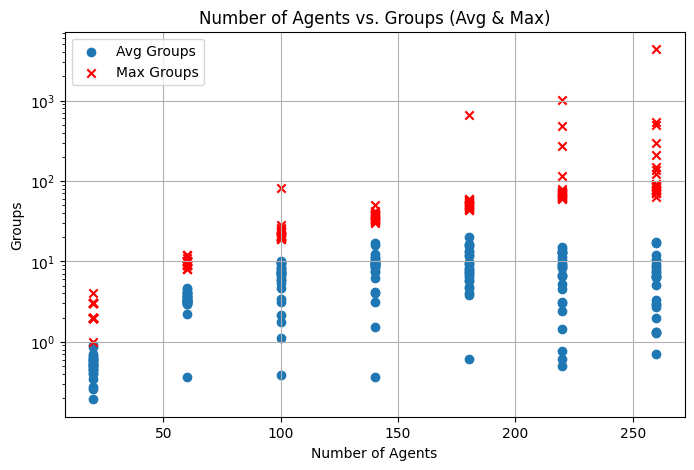

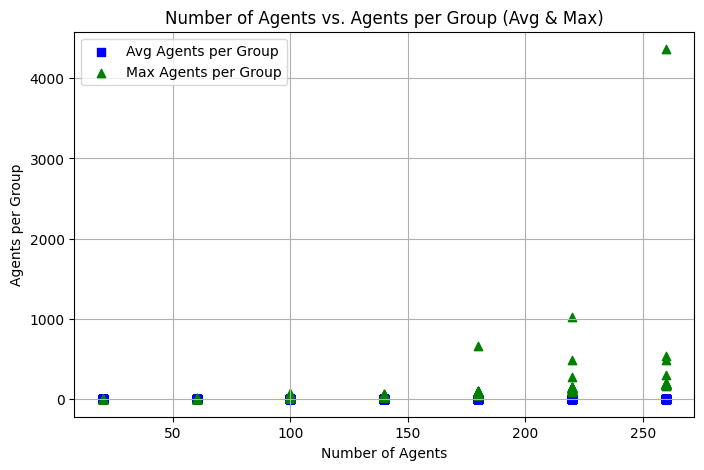

In [ ]:
folder_path = "outputs/lacam_3232_groupinfo"  # Update this to your folder path
data_points = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        
        match = re.search(r"_(\d+)\.csv$", file)
        if match:
            num_agents = int(match.group(1))

        # Read the CSV file (variable columns)
        df = pd.read_csv(file_path, header=None).iloc[1:, :]

        # Compute average number of groups per row
        avg_groups = (df != 0).sum(axis=1).mean()
        max_groups = (df != 0).sum(axis=1).max()  # Maximum number of groups in any row

        # Compute average number of agents per group
        avg_agents_per_group = df[df != 0].mean(axis=1).mean()  # Mean of nonzero column values
        max_agents_per_group = df[df != 0].max(axis=1).max()  # Max value of any nonzero column

        data_points.append((num_agents, avg_groups, max_groups, avg_agents_per_group, max_agents_per_group))

# Convert to DataFrame
df_plot = pd.DataFrame(data_points, columns=["Number of Agents", "Average Number of Groups", "Max Number of Groups", "Average Agents per Group", "Max Agents per Group"])

# Filter to keep only agent counts with at least 25 occurrences
df_plot = df_plot.groupby("Number of Agents").filter(lambda x: len(x) >= 25)
df_plot.sort_values(by="Number of Agents", inplace=True)

# Plot 1: Number of Agents vs. Average & Max Number of Groups
plt.figure(figsize=(8, 5))
plt.scatter(df_plot["Number of Agents"], df_plot["Average Number of Groups"], marker='o', label="Avg Groups")
plt.scatter(df_plot["Number of Agents"], df_plot["Max Number of Groups"], marker='x', color='r', label="Max Groups")
plt.xlabel("Number of Agents")
plt.ylabel("Groups")
plt.yscale('log')
plt.title("Number of Agents vs. Groups (Avg & Max)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Number of Agents vs. Average & Max Agents per Group
plt.figure(figsize=(8, 5))
plt.scatter(df_plot["Number of Agents"], df_plot["Average Agents per Group"], marker='s', color='b', label="Avg Agents per Group")
plt.scatter(df_plot["Number of Agents"], df_plot["Max Agents per Group"], marker='^', color='g', label="Max Agents per Group")
plt.xlabel("Number of Agents")
plt.ylabel("Agents per Group")
plt.title("Number of Agents vs. Agents per Group (Avg & Max)")
plt.legend()
plt.grid(True)
plt.show()
